In [45]:
# ========================================
# 1. LIBRERÍAS
# ========================================

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [46]:
# ========================================
# RUTAS
# ========================================

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_PRENSA = (
    BASE
    / "01_data"
    / "03_final"
    / "prensa"
)

RUTA_MENEAME = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "meneame"
)

RUTA_FOROCOCHES = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "forocoches"
)

RUTA_YOUTUBE = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "youtube"
)

RUTA_FINAL_RRSS = (
    BASE
    / "01_data"
    / "03_final"
    / "rrss"
)

RUTA_TABLAS = (
    BASE
    / "03_outputs"
    / "tables"
    / "comparativa_plataformas"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "comparativa_plataformas"
)

RUTA_FINAL_RRSS.mkdir(parents=True, exist_ok=True)
RUTA_TABLAS.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

In [47]:
# ========================================
# CARGA DE DATASETS
# ========================================

prensa = pd.read_csv(
    RUTA_PRENSA
    / "prensa_final.csv"
)

meneame = pd.read_csv(
    RUTA_MENEAME
    / "meneame_comentarios_analizados.csv"
)

forocoches = pd.read_csv(
    RUTA_FOROCOCHES
    / "forocoches_sentimiento.csv"
)

youtube = pd.read_csv(
    RUTA_YOUTUBE
    / "youtube_comentarios_analizados.csv"
)

In [48]:
rutas = {
    "Prensa": RUTA_PRENSA,
    "Menéame": RUTA_MENEAME,
    "ForoCoches": RUTA_FOROCOCHES,
    "YouTube": RUTA_YOUTUBE
}

for nombre, ruta in rutas.items():
    print(f"{nombre}: {ruta}")
    print(f"Existe: {ruta.exists()}")
    print()

Prensa: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\03_final\prensa
Existe: True

Menéame: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\meneame
Existe: True

ForoCoches: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\forocoches
Existe: True

YouTube: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\youtube
Existe: True



In [49]:
datasets = {
    "Prensa": prensa,
    "Menéame": meneame,
    "ForoCoches": forocoches,
    "YouTube": youtube
}

for nombre, df in datasets.items():
    print("=" * 80)
    print(nombre)
    print("=" * 80)
    print(f"Filas: {len(df):,}")
    print(f"Columnas: {len(df.columns)}")
    print(df.columns.tolist())
    print()

Prensa
Filas: 4
Columnas: 11
['year_dataset', 'hostilidad_explicita_xeno', 'marco_conflictivo_xeno', 'neutro_xeno', 'sin_mencion_xeno', 'violencia_discriminacion_xeno', 'hostilidad_explicita_lgtb', 'marco_conflictivo_lgtb', 'neutro_lgtb', 'sin_mencion_lgtb', 'violencia_discriminacion_lgtb']

Menéame
Filas: 27,490
Columnas: 36
['tema', 'tema_inmigracion', 'tema_lgtbi', 'url_meneame', 'id_noticia_meneame', 'id_comentario', 'numero_comentario', 'responde_a_numero', 'es_respuesta', 'usuario', 'fecha_comentario_utc', 'fecha', 'anio', 'mes', 'votos', 'karma', 'numero_caracteres', 'numero_palabras', 'texto_original', 'texto', 'texto_analisis', 'texto_minusculas', 'texto_lexico', 'nivel_xenofobia_rrss', 'nivel_lgtbifobia_rrss', 'terminos_xenofobia_rrss', 'terminos_lgtbifobia_rrss', 'count_xeno_neutro_rrss', 'count_xeno_conflicto_rrss', 'count_xeno_hostilidad_rrss', 'count_xeno_violencia_rrss', 'count_lgtbi_neutro_rrss', 'count_lgtbi_conflicto_rrss', 'count_lgtbi_hostilidad_rrss', 'count_lgtbi_

In [51]:
# ========================================
# NORMALIZACIÓN DE MENÉAME
# ========================================

meneame_master = pd.DataFrame({
    "plataforma": "Menéame",
    "anio": pd.to_numeric(meneame["anio"], errors="coerce"),
    "tema": meneame["tema"],
    "texto": meneame["texto"],
    "sentimiento": meneame["sentimiento"],
    "nivel_xenofobia": meneame["nivel_xenofobia_rrss"],
    "nivel_lgtbifobia": meneame["nivel_lgtbifobia_rrss"],
    "topic": (
    meneame["topic"]
    if "topic" in meneame.columns
    else pd.NA
    ),
    "interacciones": pd.to_numeric(meneame["votos"], errors="coerce")
})

In [52]:
# ========================================
# NORMALIZACIÓN DE FOROCOCHES
# ========================================

forocoches_master = pd.DataFrame({
    "plataforma": "ForoCoches",
    "anio": pd.to_numeric(forocoches["anio_comentario"], errors="coerce"),
    "tema": forocoches["tema"],
    "texto": forocoches["texto"],
    "sentimiento": forocoches["sentimiento"],
    "nivel_xenofobia": forocoches["nivel_xenofobia_rrss"],
    "nivel_lgtbifobia": forocoches["nivel_lgtbifobia_rrss"],
    "topic": pd.NA,
    "interacciones": pd.NA
})

In [53]:
# ========================================
# NORMALIZACIÓN DE YOUTUBE
# ========================================

youtube_master = pd.DataFrame({
    "plataforma": "YouTube",
    "anio": pd.to_numeric(youtube["año_video"], errors="coerce"),
    "tema": youtube["tema"],
    "texto": youtube["texto"],
    "sentimiento": youtube["sentimiento"],
    "nivel_xenofobia": youtube["nivel_xenofobia_rrss"],
    "nivel_lgtbifobia": youtube["nivel_lgtbifobia_rrss"],
    "topic": youtube["topic"],
    "interacciones": pd.to_numeric(youtube["likes"], errors="coerce")
})

Creamos el maestro de RRSS

In [54]:
rrss_master = pd.concat(
    [
        meneame_master,
        forocoches_master,
        youtube_master
    ],
    ignore_index=True
)

rrss_master["anio"] = rrss_master["anio"].astype("Int64")

print(rrss_master.shape)
rrss_master.head()

(84177, 9)


,plataforma,anio,tema,texto,sentimiento,nivel_xenofobia,nivel_lgtbifobia,topic,interacciones
0,Menéame,2015,inmigracion,Unos inmigrantes en el mar en medio de una tem...,NEG,neutro,sin_mencion,<NA>,2
1,Menéame,2015,inmigracion,"#1 => #0 "" varios testigos afirmaron que, ante...",NEG,sin_mencion,sin_mencion,<NA>,0
2,Menéame,2015,lgtbi,¿Privada?,NEU,sin_mencion,sin_mencion,<NA>,0
3,Menéame,2015,lgtbi,Me la pela a quién reciba el papa,NEG,sin_mencion,sin_mencion,<NA>,0
4,Menéame,2015,lgtbi,http://www.elmundo.es/madrid/2014/03/05/531714...,NEU,sin_mencion,neutro,<NA>,8


In [55]:
# ========================================
# Filtrar únicamente los años del estudio
# ========================================

ANIOS_ESTUDIO = [2015, 2016, 2019, 2023]

rrss_master = rrss_master[
    rrss_master["anio"].isin(ANIOS_ESTUDIO)
].copy()

In [56]:
rrss_master.to_csv(
    RUTA_FINAL_RRSS
    / "rrss_master.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Guardado en:",
    RUTA_FINAL_RRSS / "rrss_master.csv"
)

Guardado en: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\03_final\rrss\rrss_master.csv


In [57]:
resumen_rrss = (
    rrss_master
    .groupby(["plataforma", "anio", "tema"], dropna=False)
    .size()
    .reset_index(name="comentarios")
    .sort_values(["plataforma", "anio", "tema"])
)

resumen_rrss

,plataforma,anio,tema,comentarios
0,ForoCoches,2015,inmigracion,827
1,ForoCoches,2015,lgtbi,619
2,ForoCoches,2016,inmigracion,2444
3,ForoCoches,2016,lgtbi,316
4,ForoCoches,2019,inmigracion,759
5,ForoCoches,2019,lgtbi,513
6,ForoCoches,2023,inmigracion,1145
7,ForoCoches,2023,lgtbi,777
8,Menéame,2015,inmigracion,2063
9,Menéame,2015,lgtbi,888


Revisamos categorías

In [58]:
for columna in [
    "sentimiento",
    "nivel_xenofobia",
    "nivel_lgtbifobia"
]:
    print("=" * 70)
    print(columna.upper())
    print("=" * 70)

    for plataforma in rrss_master["plataforma"].unique():
        valores = (
            rrss_master.loc[
                rrss_master["plataforma"] == plataforma,
                columna
            ]
            .dropna()
            .value_counts()
        )

        print(f"\n{plataforma}")
        print(valores)

SENTIMIENTO

Menéame
sentimiento
NEG    18693
NEU     7403
POS     1394
Name: count, dtype: int64

ForoCoches
sentimiento
NEG    4849
NEU    2100
POS     451
Name: count, dtype: int64

YouTube
sentimiento
NEG    20078
NEU    16988
POS    12221
Name: count, dtype: int64
NIVEL_XENOFOBIA

Menéame
nivel_xenofobia
sin_mencion                 23305
neutro                       3030
marco_conflictivo             909
hostilidad_explicita          239
violencia_discriminacion        7
Name: count, dtype: int64

ForoCoches
nivel_xenofobia
sin_mencion                 6193
neutro                       581
marco_conflictivo            343
hostilidad_explicita         276
violencia_discriminacion       7
Name: count, dtype: int64

YouTube
nivel_xenofobia
sin_mencion                 45623
neutro                       2538
marco_conflictivo             940
hostilidad_explicita          185
violencia_discriminacion        1
Name: count, dtype: int64
NIVEL_LGTBIFOBIA

Menéame
nivel_lgtbifobia
sin_mencio

In [59]:
# ==================================================
# GRÁFICO 1
# ¿Qué plataforma presenta un discurso más negativo?
# ==================================================

sentimiento_pct = (
    rrss_master
    .groupby("plataforma")["sentimiento"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

sentimiento_pct.head()

,plataforma,sentimiento,porcentaje
0,ForoCoches,NEG,65.527027
1,ForoCoches,NEU,28.378378
2,ForoCoches,POS,6.094595
3,Menéame,NEG,67.999272
4,Menéame,NEU,26.929793


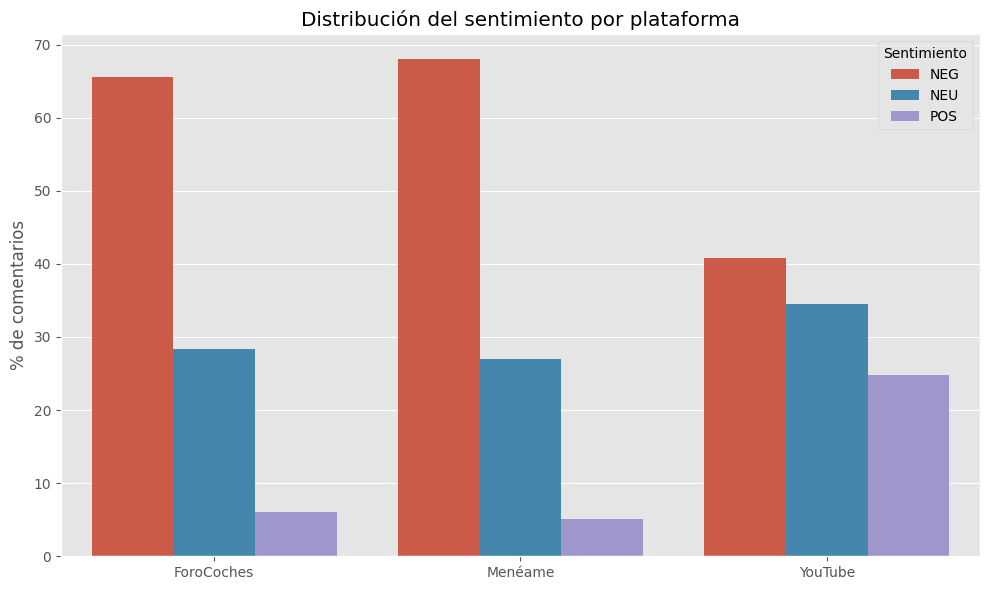

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sentimiento_pct,
    x="plataforma",
    y="porcentaje",
    hue="sentimiento"
)

plt.title("Distribución del sentimiento por plataforma")
plt.xlabel("")
plt.ylabel("% de comentarios")

plt.legend(title="Sentimiento")

plt.tight_layout()

plt.show()

In [61]:
sentimiento_pct.pivot(
    index="plataforma",
    columns="sentimiento",
    values="porcentaje"
).round(2)

sentimiento,NEG,NEU,POS
plataforma,,,
ForoCoches,65.53,28.38,6.09
Menéame,68.00,26.93,5.07
YouTube,40.74,34.47,24.80


In [62]:
# ====================================================
# GRÁFICO 2
# ¿Qué plataforma presenta mayor discurso xenófobo?
# ====================================================

xeno = rrss_master[
    rrss_master["nivel_xenofobia"] != "sin_mencion"
].copy()

xeno_pct = (
    xeno
    .groupby("plataforma")["nivel_xenofobia"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

xeno_pct.head()

,plataforma,nivel_xenofobia,porcentaje
0,ForoCoches,neutro,48.135874
1,ForoCoches,marco_conflictivo,28.417564
2,ForoCoches,hostilidad_explicita,22.866611
3,ForoCoches,violencia_discriminacion,0.579950
4,Menéame,neutro,72.401434


In [63]:
orden = [
    "neutro",
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

xeno_pct["nivel_xenofobia"] = pd.Categorical(
    xeno_pct["nivel_xenofobia"],
    categories=orden,
    ordered=True
)

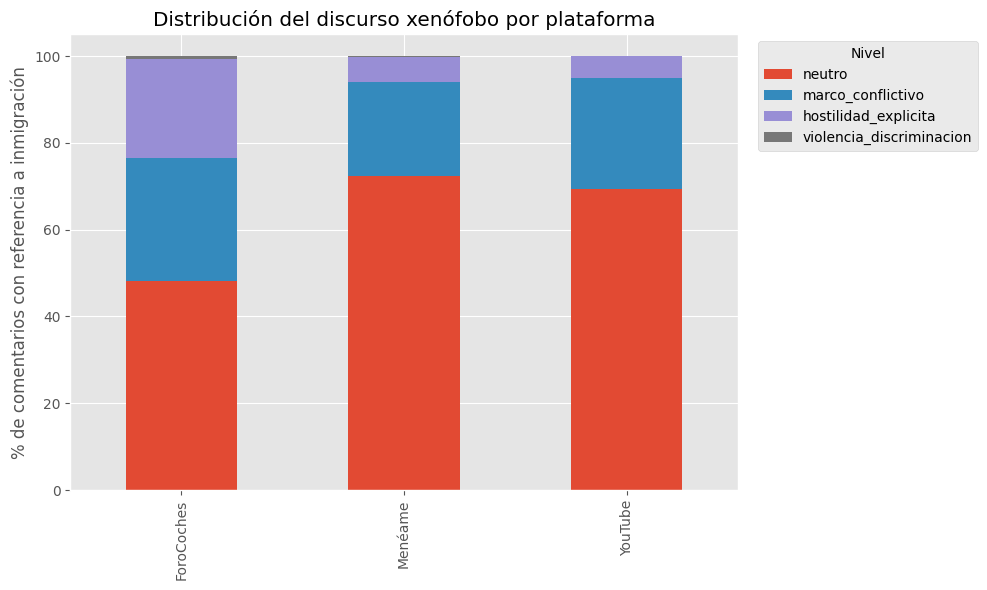

In [64]:
tabla = (
    xeno_pct
    .pivot(
        index="plataforma",
        columns="nivel_xenofobia",
        values="porcentaje"
    )
    .fillna(0)
)

tabla = tabla[orden]

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Distribución del discurso xenófobo por plataforma")
plt.xlabel("")
plt.ylabel("% de comentarios con referencia a inmigración")

plt.legend(
    title="Nivel",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [65]:
tabla.round(2)

nivel_xenofobia,neutro,marco_conflictivo,hostilidad_explicita,violencia_discriminacion
plataforma,,,,
ForoCoches,48.14,28.42,22.87,0.58
Menéame,72.40,21.72,5.71,0.17
YouTube,69.27,25.66,5.05,0.03


In [66]:
# ====================================================
# GRÁFICO 3
# ¿Qué plataforma presenta mayor discurso LGTBIfóbico?
# ====================================================

lgtbi = rrss_master[
    rrss_master["nivel_lgtbifobia"] != "sin_mencion"
].copy()

lgtbi_pct = (
    lgtbi
    .groupby("plataforma")["nivel_lgtbifobia"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

orden = [
    "neutro",
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

lgtbi_pct["nivel_lgtbifobia"] = pd.Categorical(
    lgtbi_pct["nivel_lgtbifobia"],
    categories=orden,
    ordered=True
)



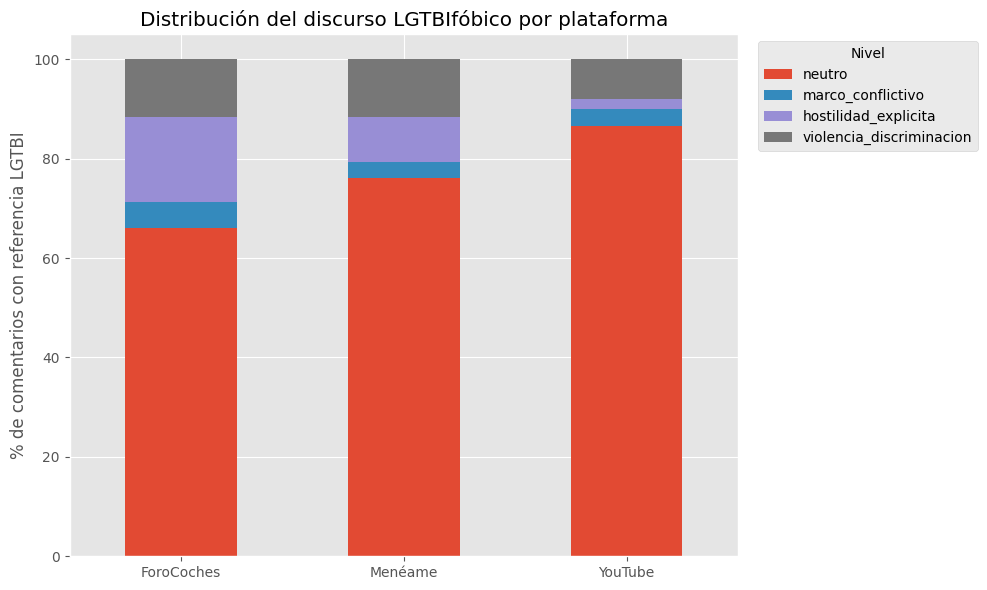

In [67]:
tabla_lgtbi = (
    lgtbi_pct
    .pivot(
        index="plataforma",
        columns="nivel_lgtbifobia",
        values="porcentaje"
    )
    .fillna(0)
)

tabla_lgtbi = tabla_lgtbi[orden]

tabla_lgtbi.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución del discurso LGTBIfóbico por plataforma")
plt.xlabel("")
plt.ylabel("% de comentarios con referencia LGTBI")

plt.legend(
    title="Nivel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [68]:
tabla_lgtbi.round(2)

nivel_lgtbifobia,neutro,marco_conflictivo,hostilidad_explicita,violencia_discriminacion
plataforma,,,,
ForoCoches,66.11,5.26,17.05,11.58
Menéame,76.13,3.17,9.16,11.53
YouTube,86.47,3.50,2.08,7.95


In [69]:
# =================================================
# GRÁFICO 4
# ¿Cómo evoluciona el sentimiento por plataforma?
# =================================================

sentimiento_anio = (
    rrss_master
    .groupby(["anio", "plataforma"])["sentimiento"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

sentimiento_anio.head()

,anio,plataforma,sentimiento,porcentaje
0,2015,ForoCoches,NEG,54.218534
1,2015,ForoCoches,NEU,37.206086
2,2015,ForoCoches,POS,8.575380
3,2015,Menéame,NEG,66.452050
4,2015,Menéame,NEU,28.126059


In [70]:
negativos = sentimiento_anio[
    sentimiento_anio["sentimiento"] == "NEG"
]

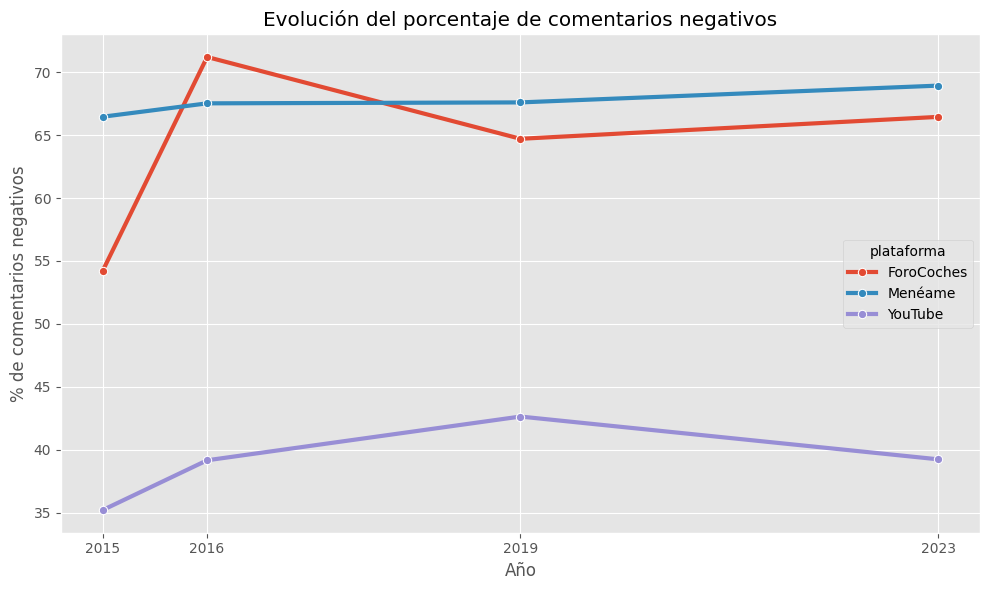

In [71]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=negativos,
    x="anio",
    y="porcentaje",
    hue="plataforma",
    marker="o",
    linewidth=3
)

plt.title("Evolución del porcentaje de comentarios negativos")
plt.xlabel("Año")
plt.ylabel("% de comentarios negativos")

plt.xticks(sorted(rrss_master["anio"].dropna().unique()))

plt.tight_layout()
plt.show()

In [72]:
# ================================================
# GRÁFICO 5
# ¿Cómo evoluciona la xenofobia por plataforma?
# ================================================

hostilidad_xeno = (
    rrss_master
    .assign(
        hostilidad=lambda df:
        df["nivel_xenofobia"] == "hostilidad_explicita"
    )
)

In [73]:
hostilidad_xeno = (
    hostilidad_xeno
    .groupby(["anio","plataforma"])["hostilidad"]
    .mean()
    .mul(100)
    .reset_index()
)

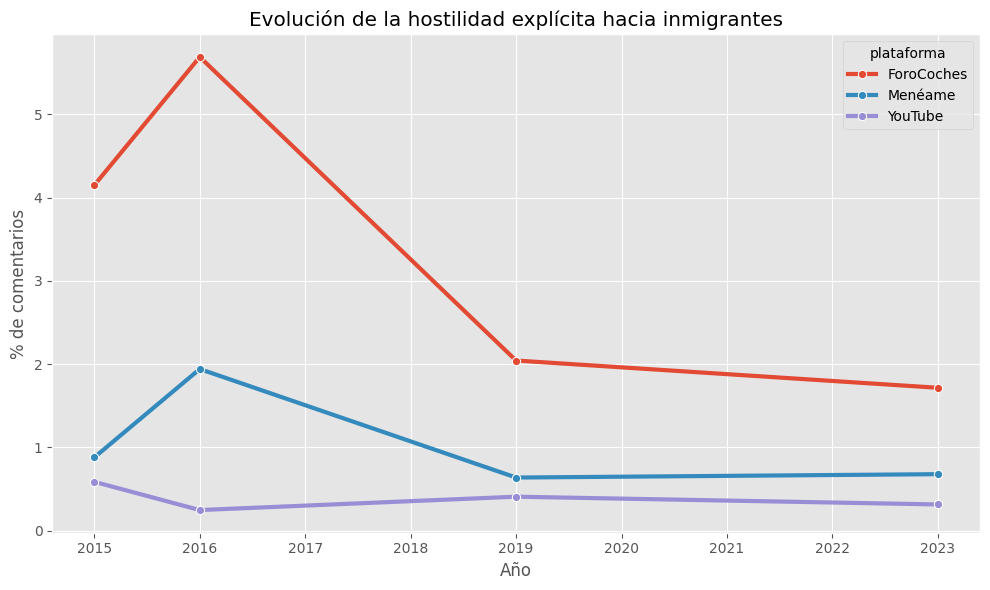

In [74]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=hostilidad_xeno,
    x="anio",
    y="hostilidad",
    hue="plataforma",
    marker="o",
    linewidth=3
)

plt.title("Evolución de la hostilidad explícita hacia inmigrantes")
plt.xlabel("Año")
plt.ylabel("% de comentarios")

plt.tight_layout()

plt.show()

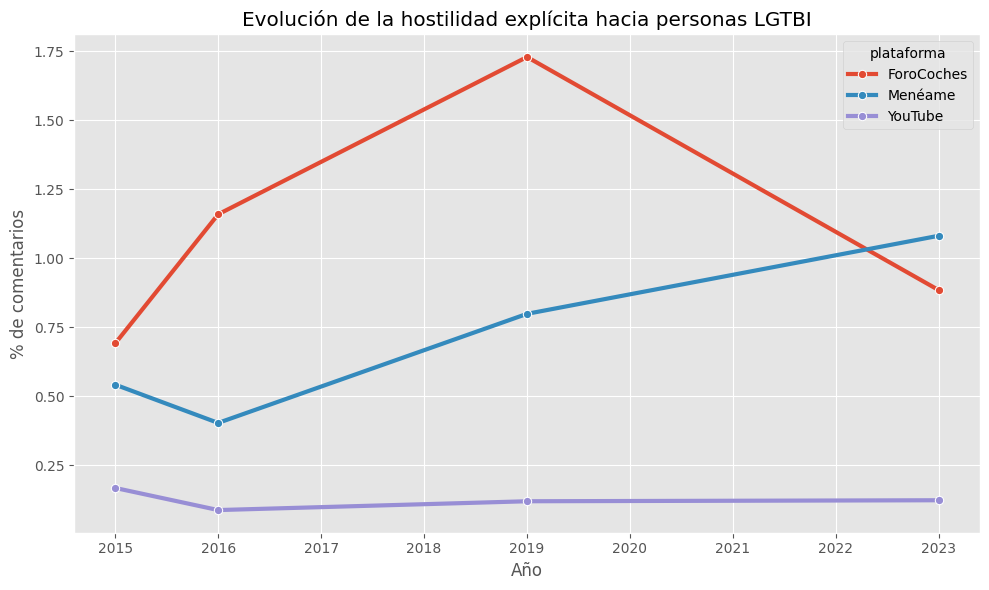

In [75]:
# ================================================
# GRÁFICO 6
# ¿Cómo evoluciona la LGTBIfobia por plataforma?
# ================================================
hostilidad_lgtbi = (
    rrss_master
    .assign(
        hostilidad=lambda df:
        df["nivel_lgtbifobia"]=="hostilidad_explicita"
    )
)

hostilidad_lgtbi = (
    hostilidad_lgtbi
    .groupby(["anio","plataforma"])["hostilidad"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=hostilidad_lgtbi,
    x="anio",
    y="hostilidad",
    hue="plataforma",
    marker="o",
    linewidth=3
)

plt.title("Evolución de la hostilidad explícita hacia personas LGTBI")
plt.xlabel("Año")
plt.ylabel("% de comentarios")

plt.tight_layout()

plt.show()

In [76]:
# =========================================================
# GRÁFICO 7A
# ¿Cómo evoluciona el discurso hostil hacia la inmigración?
# =========================================================

niveles_hostiles = [
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

xeno_time = rrss_master.copy()

xeno_time["hostil"] = (
    xeno_time["nivel_xenofobia"]
    .isin(niveles_hostiles)
)

evolucion_xeno = (
    xeno_time
    .groupby(["anio", "plataforma"])["hostil"]
    .mean()
    .mul(100)
    .reset_index(name="porcentaje")
)

evolucion_xeno.head()

,anio,plataforma,porcentaje
0,2015,ForoCoches,6.293223
1,2015,Menéame,3.761437
2,2015,YouTube,1.007275
3,2016,ForoCoches,10.652174
4,2016,Menéame,4.842371


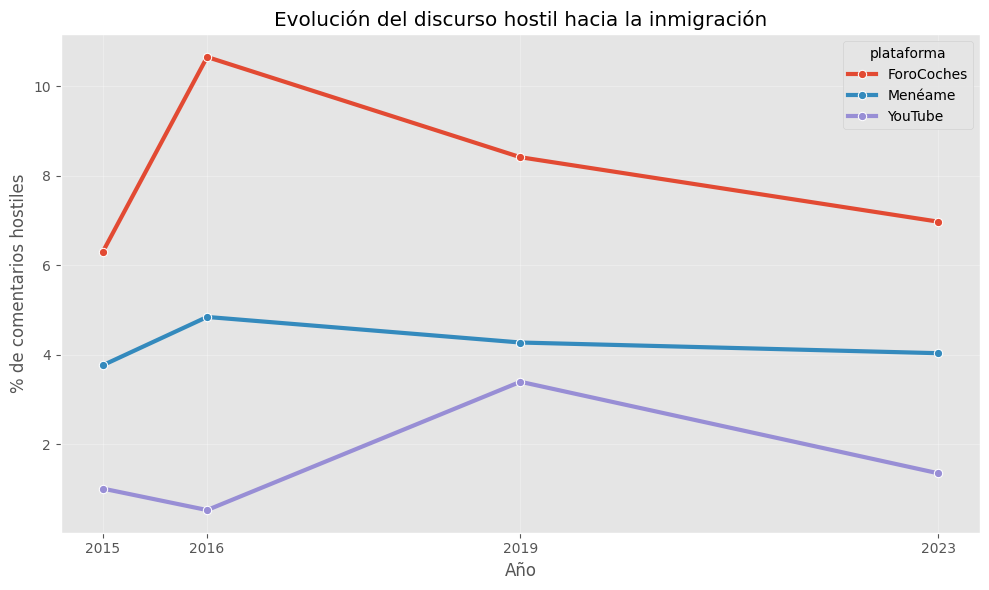

In [77]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=evolucion_xeno,
    x="anio",
    y="porcentaje",
    hue="plataforma",
    marker="o",
    linewidth=3
)

plt.title("Evolución del discurso hostil hacia la inmigración")
plt.xlabel("Año")
plt.ylabel("% de comentarios hostiles")

plt.xticks(sorted(rrss_master["anio"].dropna().unique()))

plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

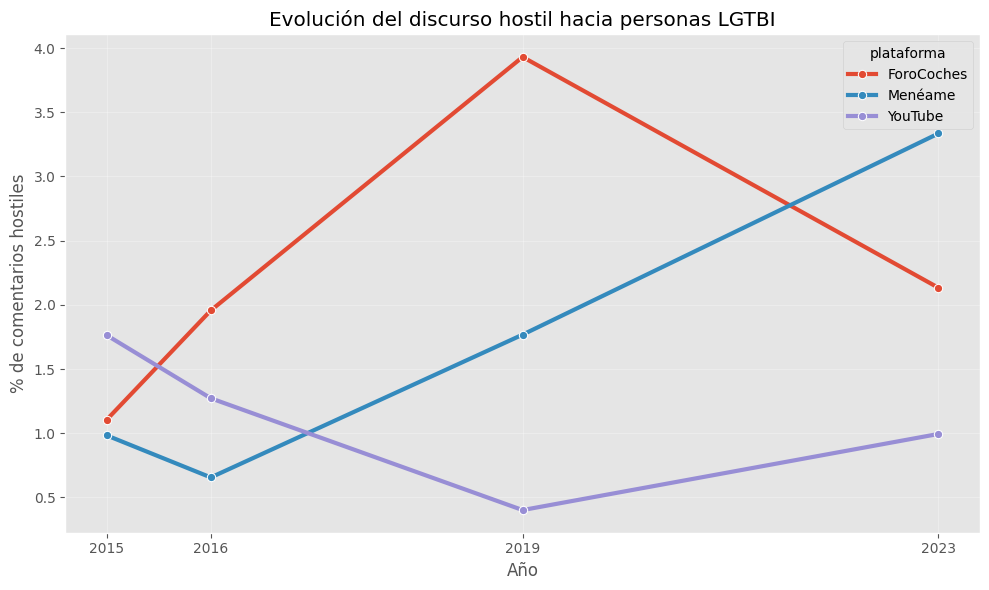

In [78]:
# =================================================================
# GRÁFICO 7B
# ¿Cómo evoluciona el discurso hostil hacia el colectivo LGTBIfobia?
# =================================================================
lgtbi_time = rrss_master.copy()

lgtbi_time["hostil"] = (
    lgtbi_time["nivel_lgtbifobia"]
    .isin(niveles_hostiles)
)

evolucion_lgtbi = (
    lgtbi_time
    .groupby(["anio", "plataforma"])["hostil"]
    .mean()
    .mul(100)
    .reset_index(name="porcentaje")
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=evolucion_lgtbi,
    x="anio",
    y="porcentaje",
    hue="plataforma",
    marker="o",
    linewidth=3
)

plt.title("Evolución del discurso hostil hacia personas LGTBI")
plt.xlabel("Año")
plt.ylabel("% de comentarios hostiles")

plt.xticks(sorted(rrss_master["anio"].dropna().unique()))

plt.grid(alpha=.3)

plt.tight_layout()
plt.show()